Permeation

In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

In [2]:
upper_end = 6.754
lower_end = -6.754

In [3]:
skip_frame = 0
output_file = "permeation.dat"


In [9]:
u = mda.Universe('system.psf','MDequil.dcd')
wat = u.select_atoms("name OH2")

seg_list = wat.segids  # Per-atom segid
resids = wat.resids    # Per-atom resid
num_atoms = len(wat)
labels = np.zeros(num_atoms, dtype=int)

num1 = 0  # +z direction count
num2 = 0  # -z direction count

In [10]:
print("Computing permeation events... (please wait)")

time=[]
permeation_pos=[]
permeation_neg=[]

with open(output_file, "w") as f:
    f.write("# frame +z -z \n")

    for ts in u.trajectory:
        z_coords = wat.positions[:, 2]
        old_labels = labels.copy()
        for i, z in enumerate(z_coords):
            old_label = old_labels[i]
            segname = seg_list[i]
            resid = resids[i]

            if z > upper_end:
                new_label = 2
                if old_label == -1:
                    print(f"{segname}:{resid} permeated through the nanotubes along +z direction at frame {ts.frame}")
                    if ts.frame >= skip_frame:
                        num1 += 1
            elif z < lower_end:
                new_label = -2
                if old_label == 1:
                    print(f"{segname}:{resid} permeated through the nanotubes along -z direction at frame {ts.frame}")
                    if ts.frame >= skip_frame:
                        num2 += 1
            elif abs(old_label) > 1:
                new_label = old_label // 2
            else:
                new_label = old_label

            labels[i] = new_label

        # accumulate data to plot
        time.append(ts.time)
        permeation_pos.append(num1)
        permeation_neg.append(num2)
        # Save data to file
        f.write(f"{round(ts.time)} {num1} {num2}\n")


Computing permeation events... (please wait)
WT1:2283 permeated through the nanotubes along +z direction at frame 7
WT1:514 permeated through the nanotubes along +z direction at frame 8
WT1:177 permeated through the nanotubes along +z direction at frame 11
WT1:2794 permeated through the nanotubes along -z direction at frame 12
WT1:3554 permeated through the nanotubes along -z direction at frame 16
WT1:895 permeated through the nanotubes along +z direction at frame 18
WT1:5356 permeated through the nanotubes along -z direction at frame 18
WT1:852 permeated through the nanotubes along +z direction at frame 20
WT1:949 permeated through the nanotubes along +z direction at frame 20
WT1:1830 permeated through the nanotubes along -z direction at frame 22
WT1:3152 permeated through the nanotubes along -z direction at frame 24
WT1:68 permeated through the nanotubes along -z direction at frame 36
WT1:947 permeated through the nanotubes along -z direction at frame 36
WT1:7945 permeated through th

In [11]:
nf = len(u.trajectory) - skip_frame
if nf >= 0:
    print(f"\nThe total number of permeation events during {nf} frames in +z direction is: {num1}")
    print(f"The total number of permeation events during {nf} frames in -z direction is: {num2}")
else:
    print(f"The specified first frame ({skip_frame}) is larger than the total number of frames.")

print("Time evolution saved in a .dat file")



The total number of permeation events during 100 frames in +z direction is: 18
The total number of permeation events during 100 frames in -z direction is: 24
Time evolution saved in a .dat file


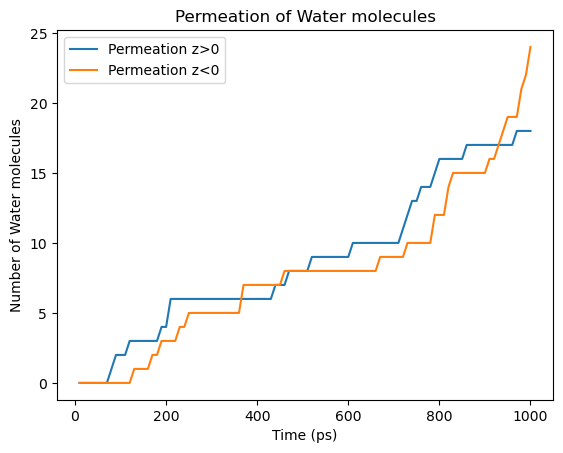

In [12]:
plt.plot(time, permeation_pos, label='Permeation z>0')
plt.plot(time, permeation_neg, label='Permeation z<0')
plt.xlabel('Time (ps)')
plt.ylabel('Number of Water molecules')
plt.title('Permeation of Water molecules')
plt.legend()
plt.show()

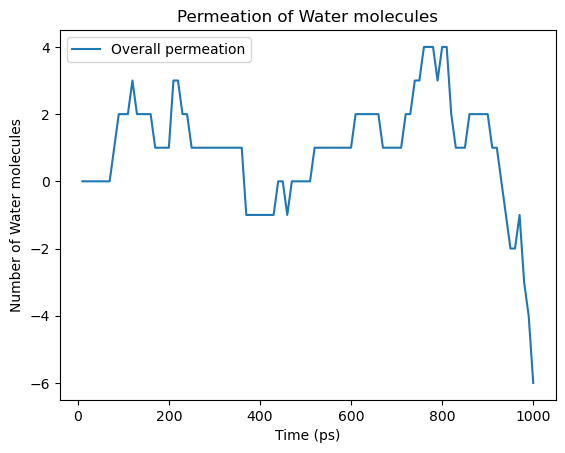

In [13]:
overall= [permeation_pos - permeation_neg for permeation_pos, permeation_neg in zip(permeation_pos, permeation_neg)]
plt.plot(time, overall, label='Overall permeation')
plt.xlabel('Time (ps)')
plt.ylabel('Number of Water molecules')
plt.title('Permeation of Water molecules')
plt.legend()
plt.show()
